In [2]:
# importing packages
import pyomo.environ as pyo
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from scipy.interpolate import griddata
import math
import scipy.stats as stats
from scipy.optimize import fsolve, bisect
import pandas as pd
import conductivity as cd
from scipy.optimize import minimize

# Conductivity of Simple Ionic Mixtures

# Double Salts Prediction

## Data for Double Salts

In [3]:
# loading NaCl and CaCl2 experiment data
data = pd.read_csv("./Data/LiCL_pH.csv")
LiCl_conc = data["LiCl_conc"]
HCl_conc_ph2 = data["HCl_conc_ph2"]
HCl_conc_ph3 = data["HCl_conc_ph3"]
HCl_conc_ph4 = data["HCl_conc_ph4"]

# number of data points
ndata = len(LiCl_conc)

## Constants

In [4]:
# temperature in K
T = 298.15

# diffusion coefficients at infinite dilution in m^2/s
Diff_Na = 1.334 * 10**(-9)
Diff_Cl = 2.032 * 10**(-9)
Diff_Ca = 0.792 * 10**(-9)
Diff_La = 0.619 * 10**(-9)
Diff_Li = 1.029 * 10**(-9)
Diff_H = 9.311 * 10**(-9)
Diff_Co = 0.732 * 10**(-9)

# valencies
z_Na = 1
z_Cl = -1
z_Ca = 2
z_La = 3
z_Li = 1
z_H = 1
z_Co = 2

# hard sphere diameters in m
sigma_Cl = 2 * 181 * 10**(-12)
sigma_Ca = 2 * 100 * 10**(-12)
sigma_La = 2 * 118 * 10**(-12)
sigma_Na = 2 * 102 * 10**(-12)
sigma_Li = 2 * 74 * 10**(-12)
sigma_H = 2 * 37 * 10**(-12)
sigma_Co = 2 * 75 * 10**(-12)

# solvent viscosity in Pa.s
eta = 0.89 * 10**(-3)

# relative permittivity
epsilon = 78.43

# limiting molar conductivity of ions in m^2.S/mol
lambda_0_Na_mol = 50.08 * 10**(-4)
lambda_0_Cl_mol = 76.31 * 10**(-4)
lambda_0_Ca_mol = 59.47 * 10**(-4)
lambda_0_La_mol = 69.7 * 10**(-4)
lambda_0_Li_mol = 38.66 * 10**(-4)
lambda_0_H_mol = 349.65 * 10**(-4)
lambda_0_Co_mol = 55 * 10**(-4)

## MSA Transport Model

### pH 2 LiCl and HCl

In [5]:
# Mean spherical approximation (MSA) transport model for multi-salt specific conductivity
def msa_transport(valency, diameters, diff_coeff, temp, eta, epsilon, lambda_0,
                  salt_1_conc, salt_2_conc=None, salt_3_conc=None):
    """Calculates the specific conductivity of single-salt, two-salt, and three-salt solutions

    Argument:
        valency: list of the valency of ions in decreasing order
        diameters: list of the corresponding hard sphere diameter of the ions in m
        diff_coeff: list of the corresponding diffusion coefficient of the ions at infinite dilution in m^2/s
        temp: integer or float value of the temperature in K
        sensor_voltage: integer or float value of the sensor measuring voltage in V
        probe_distance: integer or float value of the distance between the probes in m
        eta: integer or float value of the viscosity in Pa.s
        epsilon: integer or float value of the relative permittivity
        lambda_0: list of the limiting equivalent conductivity of the ions in S.m^2/mol
        salt_1_conc = Pandas series or list of the concentration of salt 1 in mM
        salt_2_conc = Pandas series or list of the concentration of salt 2 in mM
        salt_3_conc = Pandas series or list of the concentration of salt 3 in mM

    Returns:
        all_cond_calc_con: specific conductivity of the salt solution in micro.S/cm"""

    # constants
    Avogadros_num = 6.022 * 10 ** 23  # Avogadro's constant
    k_B = 1.381 * 10 ** (-23)  # Boltzmann constant in J/K
    charge = 1.602 * 10 ** (-19)  # elementary charge in C
    epsilon_0 = 8.854 * 10 ** (-12)  # permittivity of free space in F/m
    Faraday = 96500  # Faraday's constant in C/mol

    # number of data points
    ndata = len(salt_1_conc)

    # number of species
    n_species = len(valency)

    # species charge
    ion_charge = [valency[i] * charge for i in range(len(valency))]

    # converting molar concentrations to number density
    if salt_2_conc is None and salt_3_conc is None:
        number_density_salt_1 = [salt_1_conc[i] * Avogadros_num for i in range(ndata)]

        # valency of cation
        valency_cation = valency[1]

        # evaluating the number density of individual species
        number_density_cat_1 = number_density_salt_1
        number_density_an = [valency_cation * number_density_salt_1[i] for i in range(ndata)]
    elif salt_2_conc is not None and salt_3_conc is None:
        number_density_salt_1 = [salt_1_conc[i] * Avogadros_num for i in range(ndata)]
        number_density_salt_2 = [salt_2_conc[i] * Avogadros_num for i in range(ndata)]

        # valency of cations
        valency_cation_1 = valency[0]
        valency_cation_2 = valency[2]

        # evaluating the number density of individual species
        number_density_cat_1 = number_density_salt_1
        number_density_cat_2 = number_density_salt_2
        number_density_an = [valency_cation_1 * number_density_salt_1[i] + valency_cation_2 * number_density_salt_2[i]
                             for i in range(ndata)]

    # calculate the bulk conductivity of the salt solution
    all_cond_calc = np.zeros(ndata)
    for n in range(ndata):  # loop through the salts concentration
        if salt_2_conc is None and salt_3_conc is None:
            # number density of species
            n_cat = number_density_cat_1[n]
            n_an = number_density_an[n]
            number_density = [n_an, n_cat]
        elif salt_2_conc is not None and salt_3_conc is None:
            # number density of species
            n_cat_1 = number_density_cat_1[n]
            n_cat_2 = number_density_cat_2[n]
            n_an = number_density_an[n]
            number_density = [n_cat_1, n_an, n_cat_2]

        # calculate the species ionic mobility (omega) and the relative ionic strength (mew)
        omega = np.zeros(n_species)
        mew = np.zeros(n_species)
        for a in range(n_species):
            omega[a] = diff_coeff[a] / (k_B * temp)
            mew[a] = number_density[a] * ion_charge[a] ** 2 / sum(
                number_density[j] * ion_charge[j] ** 2 for j in range(n_species))

        # calculate the Debye length from equation (5)
        kappa = math.sqrt(
            sum(number_density[l] * ion_charge[l] ** 2 / (epsilon * epsilon_0 * k_B * temp) for l in range(n_species)))

        # calculate the mean mobility from equation (7)
        omega_bar = sum(mew[j] * omega[j] for j in range(n_species))

        # calculate the transport number of all species from equation (8)
        transport_num = np.zeros(n_species)
        for j in range(n_species):
            transport_num[j] = mew[j] * omega[j] / omega_bar
        # print("The transport number is:",transport_num)

        # calculate the value of alpha from the function containing alpha
        alpha_scaled = np.zeros(n_species)
        def func_alpha(alpha_scaled):
            """
            Evaluates residuals of equation 12

            Arguments:
                alpha_scaled = alpha/omega_bar

            Returns:
                residual of equation 12
            """
            return ((alpha_scaled) * sum(
                transport_num[k] / ((omega[k] / omega_bar) ** 2 - (alpha_scaled) ** 2) for k in range(n_species)))

        # since alpha is scaled by omega_bar, omega need to be scaled by same factor
        omega_scaled = np.zeros(n_species)
        for k in range(n_species):
            omega_scaled[k] = omega[k] / omega_bar
        print("Scaled omega: ",omega_scaled)
        
        # updating the values of alpha_scaled
        for p in range(n_species):
            if p == 0:
                alpha_scaled[p] = bisect(func_alpha, 0, 0.991 * omega_scaled[p])
            else:
                alpha_scaled[p] = bisect(func_alpha, 1.0001 * omega_scaled[p - 1], 0.9991 * omega_scaled[p])

        # re-scaling alpha_scaled back to alpha
        alphas = [alpha_scaled[p] * omega_bar for p in range(n_species)]

        # calculate the q and N values of all species
        q = np.zeros(n_species)
        N = np.zeros(n_species)
        for p in range(n_species):
            q[p] = sum(omega_bar * transport_num[r] / (omega[r] + alphas[p]) for r in range(n_species))
            N[p] = math.sqrt(1 / sum(
                transport_num[r] * omega[r] ** 2 / (omega[r] ** 2 - alphas[p] ** 2) ** 2 for r in range(n_species)))

        # ksi matrix
        ksi = np.zeros((n_species, n_species))

        # calculate the hydrodynamic correction
        delta_vel_divide_vel = np.zeros(n_species)
        for i in range(n_species):
            # update the hydrodynamic correction; equation (16) divide equation (2)
            prefactor = -(Faraday ** 2) * np.abs(valency[i]) / (
                        12 * math.pi * epsilon_0 * epsilon * eta * k_B * temp * Avogadros_num * lambda_0[i])
            delta_vel_divide_vel[i] = prefactor * sum(number_density[j] * ion_charge[j] ** 2 *
                                                      ((np.exp(kappa * (diameters[i] - 0.5 * (
                                                                  diameters[i] + diameters[j]))) / (
                                                                    kappa * (1 + kappa * diameters[i]))) +
                                                       (np.exp(kappa * (diameters[j] - 0.5 * (
                                                                   diameters[i] + diameters[j]))) / (
                                                                    kappa * (1 + kappa * diameters[j]))))
                                                      for j in range(n_species))

            # update the ksi matrix
            for p in range(n_species):
                ksi[i][p] = N[p] * omega[i] / (omega[i] ** 2 - alphas[p] ** 2)

        # calculate the conductivity of the species
        cond_species = np.zeros(n_species)

        # calculate the relaxation correction
        delta_k_divide_k = np.zeros(n_species)
        for i in range(n_species):
            delta_k_divide_k_sum = 0.0
            for p in range(n_species):
                inner_delta_k_divide_k_sum = 0.0
                for j in range(n_species):
                    for a in range(n_species):
                        # calculate the average diameter
                        sigma_aj = 0.5 * (diameters[a] + diameters[j])

                        # first fraction of summation term
                        term1 = transport_num[j] * ksi[j][p] * mew[a] * (
                                ion_charge[a] * omega[a] - ion_charge[j] * omega[j]) / (
                                        ion_charge[a] * ion_charge[j] * (omega[a] + omega[j]))

                        # second fraction of summation term
                        term2 = math.sinh(kappa * math.sqrt(q[p]) * sigma_aj) / (kappa * math.sqrt(q[p]) * sigma_aj)

                        # evaluate the integral term
                        integral_prefactor = - (charge ** 2 * valency[a] * valency[j]) / (
                                    8 * math.pi * epsilon_0 * epsilon * k_B * temp)

                        integral_term1 = np.exp(kappa * diameters[j]) / (1 + kappa * diameters[j])
                        integral_term2 = np.exp(kappa * diameters[a]) / (1 + kappa * diameters[a])

                        integral_exp_term = np.exp(-kappa * (1 + np.sqrt(q[p])) * sigma_aj) / (
                                    kappa * (1 + np.sqrt(q[p])))

                        integral = integral_prefactor * (integral_term1 + integral_term2) * integral_exp_term

                        inner_delta_k_divide_k_sum += term1 * term2 * integral

                delta_k_divide_k_sum += ksi[i][p] * inner_delta_k_divide_k_sum

            # update the relaxation correction
            delta_k_divide_k[i] = -(kappa ** 2) * ion_charge[i] * delta_k_divide_k_sum / 3

            # update the conductivity of the species
            cond_species[i] = (charge ** 2) * number_density[i] * diff_coeff[i] * (valency[i] ** 2) * (
                    1 + delta_vel_divide_vel[i]) * (1 + delta_k_divide_k[i]) / (k_B * temp)

        # calculate the bulk conductivity of the solution
        all_cond_calc[n] = sum(cond_species)

    # convert the calculated conductivity from S/m to micro.S/cm
    cond_calc_con = [all_cond_calc[i] * 10 ** 6 / 100 for i in range(ndata)]

    print(f"Relaxation correction: {delta_k_divide_k}")
    print(f"Hydrodynamic correction: {delta_vel_divide_vel}")
    print(f"omega_bar: {omega_bar}")
    print(f"Alpha: {alphas}")
    print(f"Mew: {mew}")
    print(f"Transport number: {transport_num}")
    print(f"Omega: {omega}")
    print(f"ksi: {ksi}")

    return cond_calc_con

In [6]:
# LiCl constants
diffusion_coeff_LiCl = [Diff_Li, Diff_Cl] # diffusion coefficients of Ca, Na, and Cl, respectively
valency_LiCl = [z_Li, z_Cl] # valencies of Ca, Na, and Cl, respectively
diameter_LiCl = [sigma_Li, sigma_Cl] # effective ionic diameters of Ca, Na, and Cl, respectively
lambda_0_Li_Cl = [lambda_0_Li_mol, lambda_0_Cl_mol]

# LiCl and HCl constants
diffusion_coeff = [Diff_Li, Diff_Cl, Diff_H] # diffusion coefficients of Ca, Na, and Cl, respectively
valency = [z_Li, z_Cl, z_H] # valencies of Ca, Na, and Cl, respectively
diameter = [sigma_Li, sigma_Cl, sigma_H] # effective ionic diameters of Ca, Na, and Cl, respectively
lambda_0_Li_H_Cl = [lambda_0_Li_mol, lambda_0_Cl_mol, lambda_0_H_mol]

# calculated conductivity in uS/cm
all_cond_calc_con_LiCl = cd.msa_transport(valency_LiCl, diameter_LiCl, diffusion_coeff_LiCl, T, eta, epsilon, lambda_0_Li_Cl, LiCl_conc)
all_cond_calc_con_ph2 = msa_transport(valency, diameter, diffusion_coeff, T, eta, epsilon, lambda_0_Li_H_Cl, LiCl_conc, HCl_conc_ph2)
all_cond_calc_con_ph3 = msa_transport(valency, diameter, diffusion_coeff, T, eta, epsilon, lambda_0_Li_H_Cl, LiCl_conc, HCl_conc_ph3)
all_cond_calc_con_ph4 = msa_transport(valency, diameter, diffusion_coeff, T, eta, epsilon, lambda_0_Li_H_Cl, LiCl_conc, HCl_conc_ph4)

Relaxation correction: [-0.03801212 -0.03801212]
Hydrodynamic correction: [-0.15302411 -0.0725485 ]
omega_bar: 371710510737.0421
Alpha: [0.0, 351189115250.81476]
Mew: [0.5 0.5]
Transport number: [0.33616465 0.66383535]
Omega: [2.49911869e+11 4.93509152e+11]
ksi: [[ 1.40525185 -1.        ]
 [ 0.71161622  1.        ]]
Scaled omega:  [0.19433261 0.38375497 1.75843627]
Scaled omega:  [0.2065712  0.40792291 1.86917827]
Scaled omega:  [0.22925983 0.4527269  2.07447841]
Scaled omega:  [0.24984066 0.49336854 2.26070594]
Scaled omega:  [0.26859438 0.53040212 2.43040067]
Scaled omega:  [0.28575396 0.5642877  2.58567065]
Scaled omega:  [0.32288431 0.63761022 2.921648  ]
Scaled omega:  [0.35350701 0.69808188 3.19874034]
Scaled omega:  [0.37919507 0.74880893 3.43118107]
Scaled omega:  [0.40105232 0.79197116 3.62895839]
Scaled omega:  [0.41987623 0.82914334 3.79928819]
Scaled omega:  [0.43625726 0.8614915  3.94751346]
Scaled omega:  [0.45064198 0.88989748 4.07767493]
Scaled omega:  [0.46337436 0.915

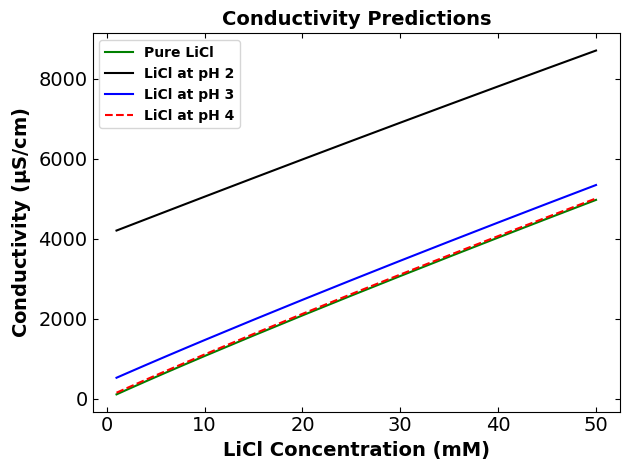

In [7]:
# making plot comparison of calculated and experimental conductivity of NaCl and CaCl2
fig = plt.figure()
plt.plot(LiCl_conc, all_cond_calc_con_LiCl, "g-", label="Pure LiCl")
plt.plot(LiCl_conc, all_cond_calc_con_ph2, color="black", linestyle="-", label="LiCl at pH 2")
plt.plot(LiCl_conc, all_cond_calc_con_ph3, "b-", label="LiCl at pH 3")
plt.plot(LiCl_conc, all_cond_calc_con_ph4, color='red', linestyle='--', label="LiCl at pH 4")
plt.xlabel("LiCl Concentration (mM)", fontsize=14,fontweight='bold')
plt.ylabel("Conductivity ($\mathbf{\mu}$S/cm)", fontsize=14,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.title("Conductivity Predictions", fontsize=14,fontweight='bold')
plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(".\Li_Co\msa_licl_ph.png")
plt.show()

## Load the data for CoCl2 non-constant pH

In [8]:
# load the data
data = pd.read_csv('.\Data\CoCl2_pH3.csv')

# get the experiment time and measurements
experiment_time_raw = data['Time (s)']
experiment_time = [experiment_time_raw[i]/60 for i in range(len(experiment_time_raw))]
ICP_conc_raw = data['ICP-OES Concentration (mM)']
sample_pH_raw = data['Observed Sample pH']
permeate_temp = data['Permeate Temp']
permeate_conc_raw = data['Permeate Concentration (mM)']
permeate_cond_raw = data['Permeate Cond @ Temp (uS/cm)']
# permeate_cond_cal = [permeate_cond_raw[i] for i in range(len(permeate_cond_raw))]

In [9]:
# convert the conductivity at recorded temperature to 25 deg. C
temp_coeff = 0.02 # per deg. C
permeate_cond_cal = [permeate_cond_raw[i] * (1 + temp_coeff * (25 - permeate_temp[i])) for i in range(len(permeate_cond_raw))]

In [10]:
# filter out the empty measurements
ICP_conc = []
sample_pH = []
exp_time_ICP_pH = []
permeate_conc = []
permeate_cond = []
for i, t in enumerate(experiment_time):
    if not pd.isna(ICP_conc_raw[i]) and not pd.isna(sample_pH_raw[i]):
        ICP_conc.append(ICP_conc_raw[i])
        sample_pH.append(sample_pH_raw[i])
        exp_time_ICP_pH.append(t)
        permeate_conc.append(permeate_conc_raw[i])
        permeate_cond.append(permeate_cond_cal[i])

print("ICP conc. in mM:\n",ICP_conc)
print("Permeate cond. in micro.S/cm:\n",permeate_cond)
print("Sample pH:\n",sample_pH)
print("Corresponding experiment time in min:\n",exp_time_ICP_pH)

ICP conc. in mM:
 [0.19278, 0.33504, 0.71337, 1.23054, 2.01759, 3.09497, 4.60706, 6.76483, 10.17519, 11.72702]
Permeate cond. in micro.S/cm:
 [632.6867360000001, 1294.5924479999999, 1221.575496, 1050.249996, 968.752776, 1105.20753, 1310.2601600000003, 1846.7681280000002, 2465.124836, 3180.54114]
Sample pH:
 [2.94, 2.66, 2.62, 2.71, 2.91, 3.07, 3.19, 3.26, 3.29, 3.27]
Corresponding experiment time in min:
 [22.009966666666667, 56.12286666666667, 80.79703333333333, 110.4561, 147.80225000000002, 196.21836666666667, 258.55469999999997, 347.13443333333333, 472.5086, 641.8151833333334]


In [11]:
# calculate the H+ concentration from the pH
ndata_pH = len(sample_pH)
H_conc = np.zeros(ndata_pH)
for i in range(ndata_pH):
    H_conc[i] = 1000 * (10 ** (-sample_pH[i]))

print("H+ conc. in mM:\n",H_conc)

H+ conc. in mM:
 [1.14815362 2.18776162 2.39883292 1.9498446  1.23026877 0.85113804
 0.64565423 0.54954087 0.51286138 0.5370318 ]


## Calculate the CoCl2 concentration from the permeate conductivity using the MSA model

In [12]:
# # temperature in K
# temp = 293.04

# # diffusion coefficients at infinite dilution in m^2/s
# diffusion_coeff = [Diff_Co, Diff_Cl]

# # valencies
# valency = [z_Co, z_Cl]

# # hard sphere diameters in m
# diameter = [sigma_Co, sigma_Cl]

# # solvent viscosity in Pa.s
# eta_msa = 1.002 * 10**(-3)

# # relative permittivity
# epsilon_msa = 80.23

# # limiting molar conductivity of ions in m^2.S/mol
# lambda_0_Co_Cl = [lambda_0_Co_mol, lambda_0_Cl_mol]

In [13]:
# temperature in K
temp = 298.15

# diffusion coefficients at infinite dilution in m^2/s
diffusion_coeff = [Diff_Co, Diff_Cl]

# valencies
valency = [z_Co, z_Cl]

# hard sphere diameters in m
diameter = [sigma_Co, sigma_Cl]

# solvent viscosity in Pa.s
eta_msa = 0.89 * 10**(-3)

# relative permittivity
epsilon_msa = 78.43

# limiting molar conductivity of ions in m^2.S/mol
lambda_0_Co_Cl = [lambda_0_Co_mol, lambda_0_Cl_mol]

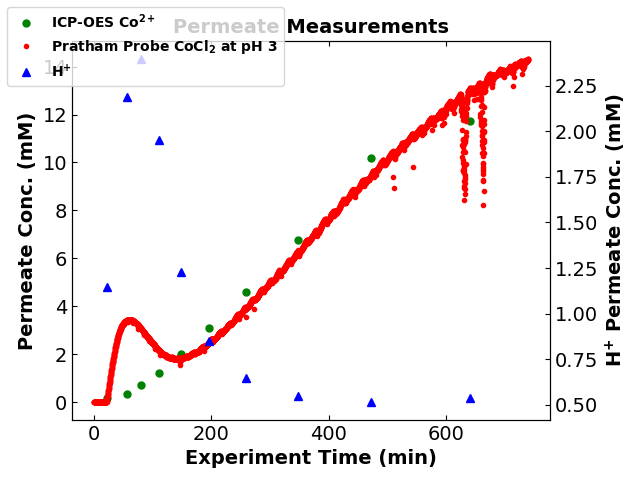

In [14]:
# make plot of the ICP Co2+ concentration and H+ sample concentration
fig, ax1 = plt.subplots()

ax1.plot(exp_time_ICP_pH, ICP_conc, "g.", markersize=10, label="ICP-OES Co$^\mathbf{2+}$")
ax1.plot(experiment_time, permeate_conc_raw, "r.", label="Pratham Probe CoCl$_\mathbf{2}$ at pH 3")
# ax1.plot(exp_time_ICP_pH, permeate_conc, "r*", markersize=10, label="Pratham Probe CoCl$_\mathbf{2}$")
ax1.set_xlabel("Experiment Time (min)", fontsize=14,fontweight='bold')
ax1.set_ylabel("Permeate Conc. (mM)", fontsize=14,fontweight='bold')
ax1.tick_params(axis='x', labelsize=14, direction="in",top=True, right=True)
ax1.tick_params(axis='y', labelsize=14, direction="in",top=True, right=True)

# Create a second y-axis sharing the same x-axis
ax2 = ax1.twinx()
ax2.plot(exp_time_ICP_pH, H_conc, "b^", label="H$^\mathbf{+}$")
ax2.tick_params(axis='y', labelsize=14, direction="in",top=True, right=True)
ax2.set_ylabel("H$^\mathbf{+}$ Permeate Conc. (mM)", fontsize=14,fontweight='bold')

fig.legend(prop={"weight":"bold"}, loc="upper left")
plt.title("Permeate Measurements", fontsize=14,fontweight='bold')
plt.tight_layout()
plt.savefig(".\Li_Co\cocl2_data.png")
plt.show()

## HCl conductivity contribution

In [15]:
# valencies
valency_H_Cl = [z_Cl, z_H]

# diffusion coefficients at infinite dilution in m^2/s
diff_coeff_H_Cl = [Diff_Cl, Diff_H]

# hard sphere diameters in m
diameter_H_Cl = [sigma_Cl, sigma_H]

# limiting molar conductivity of ions in m^2.S/mol
lambda_0_H_Cl = [lambda_0_Cl_mol, lambda_0_H_mol]

# HCl concentration in mM
HCl_conc = H_conc

# calculate the bulk conductivity using the MSA transport model
HCl_cond = msa_transport(valency_H_Cl, diameter_H_Cl, diff_coeff_H_Cl, temp, eta_msa, epsilon_msa, lambda_0_H_Cl, HCl_conc)

Scaled omega:  [0.35828264 1.64171736]
Scaled omega:  [0.35828264 1.64171736]
Scaled omega:  [0.35828264 1.64171736]
Scaled omega:  [0.35828264 1.64171736]
Scaled omega:  [0.35828264 1.64171736]
Scaled omega:  [0.35828264 1.64171736]
Scaled omega:  [0.35828264 1.64171736]
Scaled omega:  [0.35828264 1.64171736]
Scaled omega:  [0.35828264 1.64171736]
Scaled omega:  [0.35828264 1.64171736]
Relaxation correction: [-0.00516601 -0.00516601]
Hydrodynamic correction: [-0.00900528 -0.0019867 ]
omega_bar: 1377429703786.4321
Alpha: [0.0, 1056407614413.83]
Mew: [0.5 0.5]
Transport number: [0.17914132 0.82085868]
Omega: [4.93509152e+11 2.26135026e+12]
ksi: [[ 2.1406039  -1.        ]
 [ 0.46715789  1.        ]]


### H+

In [16]:
# valencies
valency_H = [z_H]

# diffusion coefficients at infinite dilution in m^2/s
diff_coeff_H = [Diff_H]

# hard sphere diameters in m
diameter_H = [sigma_H]

# limiting molar conductivity of ions in m^2.S/mol
lambda_0_H = [lambda_0_H_mol]

# calculate the bulk conductivity using the MSA transport model
H_cond = cd.msa_transport(valency_H, diameter_H, diff_coeff_H, temp, eta_msa, epsilon_msa, lambda_0_H, H_conc)

Relaxation correction: [-0.]
Hydrodynamic correction: [-0.00141471]
omega_bar: 2261350255127.474
Alpha: [0.0]
Mew: [1.]
Transport number: [1.]
Omega: [2.26135026e+12]
ksi: [[1.]]


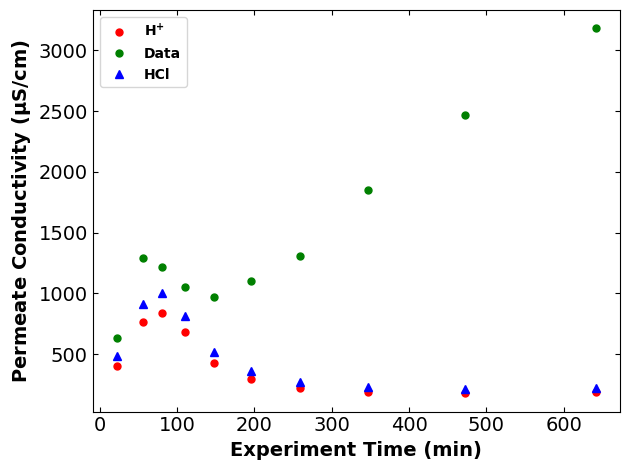

In [17]:
# making plot comparison of data values and calculated
plt.plot(exp_time_ICP_pH, H_cond, "r.", markersize=10, label="H$^\mathbf{+}$")
plt.plot(exp_time_ICP_pH, permeate_cond, "g.", markersize=10, label="Data")
plt.plot(exp_time_ICP_pH, HCl_cond, "b^", label="HCl")
plt.xlabel("Experiment Time (min)", fontsize=14,fontweight='bold')
plt.ylabel("Permeate Conductivity ($\mathbf{\mu}$S/cm)", fontsize=14,fontweight='bold')
plt.tick_params(axis='x', labelsize=14, direction="in",top=True, right=True)
plt.tick_params(axis='y', labelsize=14, direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(".\Li_Co\cocl2_conductivity.png")
plt.show()

## Co2+ conductivity and concentration method 2

In [18]:
# CoCl2 and HCl constants
diff_coeff_Co_Cl_H = [Diff_Co, Diff_Cl, Diff_H] # diffusion coefficients of Ca, Na, and Cl, respectively
valency_Co_Cl_H = [z_Co, z_Cl, z_H] # valencies of Ca, Na, and Cl, respectively
diameter_Co_Cl_H = [sigma_Co, sigma_Cl, sigma_H] # effective ionic diameters of Ca, Na, and Cl, respectively
lambda_0_Co_Cl_H = [lambda_0_Co_mol, lambda_0_Cl_mol, lambda_0_H_mol]

In [19]:
# # create the objective function of the optimization problem
# def SSE_permeate_Co_H(salt_conc):
#     """
#     Calculates the sum of squared errors between the variant Shedlovsky and MSA Transport model

#     Argument:
#         salt_conc: concentration of the salt in mM"""

#     # calculate the bulk conductivity using the MSA transport model
#     msa_cond = msa_transport(valency_Co_Cl_H, diameter_Co_Cl_H, diff_coeff_Co_Cl_H, temp, eta_msa, epsilon_msa, lambda_0_Co_Cl_H, 
#                                 salt_conc, HCl_conc)

#     # calculate the sum of squared errors between the measured and predicted salt conductivity 
#     sse = sum((permeate_cond[i] - msa_cond[i])**2 for i in range(ndata_pH))
    
#     return sse

In [20]:
# create the objective function of the optimization problem
def SSE_permeate_Co_H(salt_conc):
    """
    Calculates the sum of squared errors between the variant Shedlovsky and MSA Transport model

    Argument:
        salt_conc: concentration of the salt in mM"""

    # calculate the bulk conductivity using the MSA transport model
    msa_cond = msa_transport(valency_Co_Cl_H, diameter_Co_Cl_H, diff_coeff_Co_Cl_H, temp, eta_msa, epsilon_msa, lambda_0_Co_Cl_H, 
                                salt_conc, HCl_conc)

    # calculate the sum of squared errors between the measured and predicted salt conductivity 
    sse = (permeate_cond[i] - msa_cond[0])**2
    
    return sse

In [21]:
# # initial guess of CoCl2 concentration in mM
# CoCl2_conc_initial = [1 for _ in range(ndata_pH)]

# # solve the optimization problem
# result = minimize(SSE_permeate_Co_H, CoCl2_conc_initial, bounds=[(1e-3, 50) for _ in range(ndata_pH)], method="L-BFGS-B")
# CoCl2_conc_method_2 = result.x

# print("The optimal CoCl2 conc. is:",CoCl2_conc_method_2)
# print("The SSE at the optimal is:",result.fun)

In [26]:
CoCl2_conc_method_2 = []
for i in range(ndata_pH):
    
    # initial guess of CoCl2 concentration in mM
    CoCl2_conc_initial = [1]

    # create the objective function of the optimization problem
    def SSE_permeate_Co_H(salt_conc):
        """
        Calculates the sum of squared errors between the variant Shedlovsky and MSA Transport model
    
        Argument:
            salt_conc: concentration of the salt in mM"""

        HCl_conc_single = [HCl_conc[i]]
    
        # calculate the bulk conductivity using the MSA transport model
        msa_cond = msa_transport(valency_Co_Cl_H, diameter_Co_Cl_H, diff_coeff_Co_Cl_H, temp, eta_msa, epsilon_msa, lambda_0_Co_Cl_H, 
                                    salt_conc, HCl_conc_single)
    
        # calculate the sum of squared errors between the measured and predicted salt conductivity 
        sse = np.abs(permeate_cond[i] - msa_cond[0])
        
        return sse
    
    # solve the optimization problem
    result = minimize(SSE_permeate_Co_H, CoCl2_conc_initial, bounds=[(1e-3, 50)], method="L-BFGS-B")
    CoCl2_conc_method_2.append(result.x)

print("The optimal CoCl2 conc. is:",CoCl2_conc_method_2)
print("The SSE at the optimal is:",result.fun)

Scaled omega:  [0.3034096  0.8422518  3.85935358]
Relaxation correction: [-0.01877029 -0.02105244 -0.02502777]
Hydrodynamic correction: [-0.06832054 -0.02410205 -0.00541582]
omega_bar: 585940160533.1692
Alpha: [0.0, 309813761926.2907, 1574528150514.9336]
Mew: [0.48214222 0.37946444 0.13839333]
Transport number: [0.14628658 0.31960461 0.53410881]
Omega: [1.77779872e+11 4.93509152e+11 2.26135026e+12]
ksi: [[ 2.28776763 -1.26061222 -0.11345984]
 [ 0.82413676  1.52668405 -0.3448194 ]
 [ 0.17985672  0.2057329   1.34074726]]
Scaled omega:  [0.3034096  0.8422518  3.85935359]
Relaxation correction: [-0.01877029 -0.02105244 -0.02502777]
Hydrodynamic correction: [-0.06832054 -0.02410205 -0.00541582]
omega_bar: 585940158342.4318
Alpha: [0.0, 309813762215.31854, 1574528153407.2427]
Mew: [0.48214222 0.37946444 0.13839333]
Transport number: [0.14628658 0.31960461 0.53410881]
Omega: [1.77779872e+11 4.93509152e+11 2.26135026e+12]
ksi: [[ 2.28776762 -1.26061222 -0.11345984]
 [ 0.82413676  1.52668405 -0

In [ ]:
# calculate the bulk conductivity using the MSA transport model
msa_cond_Co_H_transport = msa_transport(valency_Co_Cl_H, diameter_Co_Cl_H, diff_coeff_Co_Cl_H, temp, eta_msa, epsilon_msa, lambda_0_Co_Cl_H, 
                            CoCl2_conc_method_2, HCl_conc)

## Co2+ conductivity and concentration method 1

In [ ]:
# calculate the pure CoCl2 conductivity
CoCl2_cond = [permeate_cond[i] - HCl_cond[i] for i in range(ndata_pH)]

print("Bulk permeate cond. in micro.S/cm:\n",permeate_cond)
print("CoCl2 permeate cond. in micro.S/cm:\n",CoCl2_cond)
print("HCl permeate cond. in micro.S/cm:\n",HCl_cond)

In [ ]:
# create the objective function of the optimization problem
def SSE_permeate_CoCl2(salt_conc):
    """
    Calculates the sum of squared errors between the variant Shedlovsky and MSA Transport model

    Argument:
        salt_conc: concentration of the salt in mM"""

    # calculate the bulk conductivity using the MSA transport model
    msa_cond = cd.msa_transport(valency, diameter, diffusion_coeff, temp, eta_msa, epsilon_msa, lambda_0_Co_Cl, salt_conc)

    # calculate the sum of squared errors between the measured and predicted salt conductivity 
    sse = sum((CoCl2_cond[i] - msa_cond[i])**2 for i in range(ndata_pH))
    
    return sse

In [ ]:
# initial guess of CoCl2 concentration in mM
CoCl2_conc_initial = [5 for _ in range(ndata_pH)]

# solve the optimization problem
result = minimize(SSE_permeate_CoCl2, CoCl2_conc_initial, bounds=[(1e-3, 50) for _ in range(ndata_pH)], method="L-BFGS-B")
CoCl2_conc = result.x

print("The optimal CoCl2 conc. is:",CoCl2_conc)
print("The SSE at the optimal is:",result.fun)

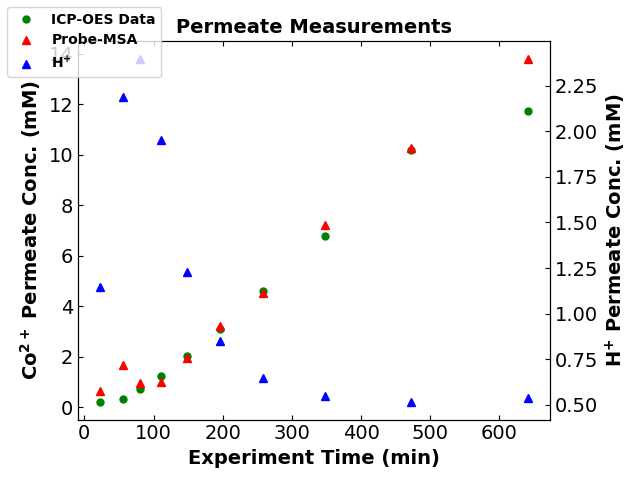

In [27]:
# make plot of the ICP Co2+ concentration and H+ sample concentration
fig, ax1 = plt.subplots()

ax1.plot(exp_time_ICP_pH, ICP_conc, "g.", markersize=10, label="ICP-OES Data")
ax1.plot(exp_time_ICP_pH, CoCl2_conc_method_2, "^", color="red", label="Probe-MSA")
# ax1.plot(exp_time_ICP_pH, CoCl2_conc, "+", color="black", markersize=10, label="Probe-MSA Method 1")
ax1.set_xlabel("Experiment Time (min)", fontsize=14,fontweight='bold')
ax1.set_ylabel("Co$^\mathbf{2+}$ Permeate Conc. (mM)", fontsize=14,fontweight='bold')
ax1.tick_params(axis='x', labelsize=14, direction="in",top=True, right=True)
ax1.tick_params(axis='y', labelsize=14, direction="in",top=True, right=True)

# Create a second y-axis sharing the same x-axis
ax2 = ax1.twinx()
ax2.plot(exp_time_ICP_pH, H_conc, "b^", label="H$^\mathbf{+}$")
ax2.tick_params(axis='y', labelsize=14, direction="in",top=True, right=True)
ax2.set_ylabel("H$^\mathbf{+}$ Permeate Conc. (mM)", fontsize=14,fontweight='bold')

fig.legend(prop={"weight":"bold"}, loc="upper left")
plt.title("Permeate Measurements", fontsize=14,fontweight='bold')
plt.tight_layout()
plt.savefig(".\Li_Co\msa_co_conc.png")
plt.show()

In [ ]:
# residuals for CaCl2 and LaCl3
e = [ICP_conc[i] - CoCl2_conc_method_2[i] for i in range(ndata_pH)]

# residuals percent or fraction
residuals_percent = [100*e[i]/ICP_conc[i] for i in range(ndata_pH)]

# absolute value of relative error
residuals_percent_abs = [np.abs(residuals_percent[i]) for i in range(ndata_pH)]
print(np.mean(residuals_percent_abs))

# make plot of the ICP Co2+ concentration and H+ sample concentration
fig, ax1 = plt.subplots()

ax1.plot(exp_time_ICP_pH, residuals_percent, "^", color="red", label="Probe-MSA")
ax1.set_xlabel("Experiment Time (min)", fontsize=14,fontweight='bold')
ax1.set_ylabel("Residuals (%)", fontsize=14,fontweight='bold')
ax1.tick_params(axis='x', labelsize=14, direction="in",top=True, right=True)
ax1.tick_params(axis='y', labelsize=14, direction="in",top=True, right=True)

fig.legend(prop={"weight":"bold"})
plt.title("Residuals Plot", fontsize=14,fontweight='bold')
plt.tight_layout()
plt.savefig(".\Li_Co\msa_co_conc_resd.png")
plt.show()

# Calibration Curve

## HCl

In [ ]:
# loading NaCl specific conductivity data
specific_data = pd.read_csv("./Data/HCl.csv")
molar_conc_specific_H = specific_data["Conc"]
specific_cond_calibrated_H = specific_data["Cond"]

# number of data points
ndata_H = len(specific_cond_calibrated_H)

In [ ]:
# constants
diffusion_coeff_HCl = [Diff_Cl, Diff_H] # diffusion coefficients of Na, and Cl, respectively
valency_HCl = [z_Cl, z_H] # valencies of Na, and Cl, respectively
diameter_HCl = [sigma_Cl, sigma_H] # effective ionic diameters of Na, and Cl, respectively
lambda_0_H_Cl = [lambda_0_Cl_mol, lambda_0_H_mol]

# calculated conductivity in uS/cm
cond_HCl = msa_transport(valency_HCl, diameter_HCl, diffusion_coeff_HCl, T, eta, epsilon, lambda_0_H_Cl, molar_conc_specific_H)

# residuals
e_HCl = [specific_cond_calibrated_H[i] - cond_HCl[i] for i in range(ndata_H)]

# residuals percent or fraction
residuals_percent_HCl = [100*e_HCl[i]/specific_cond_calibrated_H[i] for i in range(ndata_H)]
print("Residuals:",residuals_percent_HCl)

# absolute value of relative error
residuals_percent_HCl_abs = [np.abs(residuals_percent_HCl[i]) for i in range(ndata_H)]
print(np.mean(residuals_percent_HCl_abs))

In [ ]:
# making plot comparison of data and calculated values
fig = plt.figure(figsize=(4,4))
plt.plot(molar_conc_specific_H, cond_HCl, "r-", label="MSA transport")
plt.plot(molar_conc_specific_H, specific_cond_calibrated_H, ".", color="black", markersize=10, label="Data")
plt.title("Theory Predictions", fontsize=16,fontweight='bold')
plt.xlabel("HCl Conc. (mM)", fontsize=16,fontweight='bold')
plt.ylabel("Conductivity ($\mathbf{\mu}$S/cm)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(".\Li_Co\msa_hcl.png")
plt.show()

In [ ]:
# making plot of residuals of calculated specific conductivity
fig = plt.figure(figsize=(4,4))
plt.plot(molar_conc_specific_H, e_HCl, "r.", label="MSA transport")
plt.title("Residuals Plot", fontsize=16,fontweight='bold')
plt.xlabel("HCl Conc. (mM)", fontsize=16,fontweight='bold')
plt.ylabel("Residuals ($\mathbf{\mu}$S/cm)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(r".\Li_Co\residuals_msa_hcl.png")
plt.show()

In [ ]:
# visualizing in plot
fig = plt.figure(figsize=(4,4))
plt.plot(molar_conc_specific_H, residuals_percent_HCl, "r.", label="MSA transport")
plt.title("Relative Error", fontsize=16,fontweight='bold')
plt.xlabel("HCl Conc. (mM)", fontsize=16,fontweight='bold')
plt.ylabel("Residuals (%)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(r".\Li_Co\proportion_msa_hcl.png")
plt.show()

## LiCl

In [ ]:
# loading NaCl specific conductivity data
specific_data = pd.read_csv("./Data/LiCl.csv")
molar_conc_specific_Li = specific_data["Conc"]
specific_cond_Li = specific_data["Cond"]

# number of data points
ndata_Li = len(specific_cond_Li)

In [ ]:
# calculated conductivity in uS/cm
cond_LiCl = cd.msa_transport(valency_LiCl, diameter_LiCl, diffusion_coeff_LiCl, T, eta, epsilon, lambda_0_Li_Cl, molar_conc_specific_Li)

# residuals
e_LiCl = [specific_cond_Li[i] - cond_LiCl[i] for i in range(ndata_Li)]

# residuals percent or fraction
residuals_percent_LiCl = [100*e_LiCl[i]/specific_cond_Li[i] for i in range(ndata_Li)]
print("Residuals:",residuals_percent_LiCl)

# absolute value of relative error
residuals_percent_LiCl_abs = [np.abs(residuals_percent_LiCl[i]) for i in range(ndata_Li)]
print(np.mean(residuals_percent_LiCl_abs))

In [ ]:
# making plot comparison of data and calculated values
fig = plt.figure(figsize=(4,4))
plt.plot(molar_conc_specific_Li, cond_LiCl, "r-", label="MSA transport")
plt.plot(molar_conc_specific_Li, specific_cond_Li, ".", color="black", markersize=10, label="Data")
plt.title("Theory Predictions", fontsize=16,fontweight='bold')
plt.xlabel("LiCl Conc. (mM)", fontsize=16,fontweight='bold')
plt.ylabel("Conductivity ($\mathbf{\mu}$S/cm)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(".\Li_Co\msa_licl.png")
plt.show()

In [ ]:
# visualizing in plot
fig = plt.figure(figsize=(4,4))
plt.plot(molar_conc_specific_Li, residuals_percent_LiCl, "r.", label="MSA transport")
plt.title("Relative Error", fontsize=16,fontweight='bold')
plt.xlabel("LiCl Conc. (mM)", fontsize=16,fontweight='bold')
plt.ylabel("Residuals (%)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(r".\Li_Co\proportion_msa_licl.png")
plt.show()